# File

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("TORUN.csv") # ETO YUNG GINAMIT KONG CSV YA CHINECK Q NA
X = df.drop('HIV_Status', axis=1)
y = df['HIV_Status']

# 1. First split to separate out the unseen TEST set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# 2. Second split to separate Train and Validation from the remaining 80%
# 0.25 x 0.8 = 0.2 (So we end up with 60% Train, 20% Val, 20% Test)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=42
)

In [2]:
df.head(10)

,Sex,Age_Group,Transmission,Healthcare_Access_Friction,Civil_Status,OFW_Status,Chemsex_Engagement,Alcohol_Sex_Risk,PrEP_Awareness,Transactional_Sex,STI_BBV_CoInfection_Any,HIV_Status
0,Female,<15,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
1,Male,15-24,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
2,Male,15-24,Male to Male Sex,2,Single,No,No,No,Yes,No TS,Yes,Reactive
3,Male,15-24,Male to Male Sex,2,Single,No,No,No,No,No TS,Yes,Reactive
4,Male,15-24,Male to Male Sex,2,Single,No,Yes,No,Yes,No TS,No,Reactive
5,Male,15-24,Male to Male/Female Sex,2,Single,No,No,Yes,Yes,Both,No,Reactive
6,Male,25-34,Male to Female Sex,2,Common-Law,No,No,No,No,No TS,No,Reactive
7,Male,25-34,Male to Male Sex,2,Single,No,No,No,Yes,No TS,No,Reactive
8,Male,25-34,Male to Male Sex,2,Single,No,No,No,No,No TS,No,Reactive
9,Male,25-34,Male to Male Sex,2,Single,No,No,Yes,Yes,Paid for sex,Yes,Reactive


# Preprocessing

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# list num and cat
numeric_features = []
categorical_features = ['Sex','Age_Group','Transmission',
                        'Healthcare_Access_Friction','Civil_Status','OFW_Status','Chemsex_Engagement',
                        'Alcohol_Sex_Risk','PrEP_Awareness','Transactional_Sex','STI_BBV_CoInfection_Any']

# 2. proprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Apply StandardScaler to numeric columns
        ('num', StandardScaler(), numeric_features),

        # Apply OneHotEncoder to categorical columns
        # handle_unknown='ignore' ensures the code won't crash if X_test has a category not seen in X_train
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not listed above (or use 'drop')
)

# 3. Fit and Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_val_processed = preprocessor.transform(X_val) 


# Convert into DataFrame AND preserve the original index
X_train_processed = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out(), index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out(), index=X_test.index)

#Convert validation set to DataFrame
X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_val.index
)


# Dealing with y columns
mapping = {'Non-Reactive': 0, 'Reactive': 1}
y_train_processed = y_train.map(mapping)
y_test_processed = y_test.map(mapping)

# ADD THIS LINE: Map the validation labels!
y_val_processed = y_val.map(mapping)

 # MODEL and THRESHOLD MOVING

In [5]:
import numpy as np
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix,           
    balanced_accuracy_score,    
    brier_score_loss,           
    precision_recall_curve
)

# 1. Define the hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200],           
    'max_depth': [None, 10, 20],          
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4]         
}

# 2. Setup tracking for the best model
best_val_auprc = -1
best_params_rf = None
best_rf_model = None

print("Tuning Random Forest strictly using the Validation Set...")

# 3. Loop through all combinations of hyperparameters
for params in ParameterGrid(param_grid_rf):
    rf = RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Train on the TRAINING set
    rf.fit(X_train_processed, y_train_processed)
    
    # Evaluate strictly on the VALIDATION set to find the best parameters
    y_val_probs = rf.predict_proba(X_val_processed)[:, 1]
    val_auprc = average_precision_score(y_val_processed, y_val_probs)
    
    # Save the best model
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_params_rf = params
        best_rf_model = rf

print(f"\nBest Parameters Found: {best_params_rf}")
print(f"Best Validation AUPRC: {best_val_auprc:.4f}")

# ---------------------------------------------------------
# STEP 2: FIND THE GOLDEN THRESHOLD ON THE *VALIDATION* SET
# ---------------------------------------------------------
print("\nFinding Golden Threshold on Validation Set...")
val_probs_rf = best_rf_model.predict_proba(X_val_processed)[:, 1]
precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_val_processed, val_probs_rf)

# Calculate F1 for all thresholds on the validation set
f1_scores_val = 2 * (precisions_val * recalls_val) / (precisions_val + recalls_val + 1e-8)
best_idx = np.argmax(f1_scores_val[:-1]) 
miku_threshold_rf = thresholds_val[best_idx]

print(f"Optimal Random Forest Threshold: {miku_threshold_rf:.4f}")

# ---------------------------------------------------------
# STEP 3: FINAL PREDICTIONS ON THE TEST SET
# ---------------------------------------------------------
print("\nEvaluating the best model on the Test Set...")
y_probs_test = best_rf_model.predict_proba(X_test_processed)[:, 1]

# Make both sets of predictions
y_pred_default = (y_probs_test >= 0.5).astype(int)
y_pred_optimal = (y_probs_test >= miku_threshold_rf).astype(int)

# Calculate AUPRC (Overall model power)
auprc_test = average_precision_score(y_test_processed, y_probs_test)

# --- METRICS CALCULATIONS ---
# Extract matrix components for Optimal
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test_processed, y_pred_optimal).ravel()
specificity_opt = tn_opt / (tn_opt + fp_opt)

# Extract matrix components for Default
tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test_processed, y_pred_default).ravel()
specificity_def = tn_def / (tn_def + fp_def)

# Calculate Balanced Accuracy and Brier Score
bal_acc_opt = balanced_accuracy_score(y_test_processed, y_pred_optimal)
bal_acc_def = balanced_accuracy_score(y_test_processed, y_pred_default)
brier = brier_score_loss(y_test_processed, y_probs_test)

# Final Printout
print("\n--- FINAL TEST SET PERFORMANCE COMPARISON ---")
print(f"{'Metric':<20} | {'Default (0.5)':<15} | {'Optimized ('+str(round(miku_threshold_rf,2))+')':<15}")
print("-" * 60)
print(f"{'F1-Score':<20} | {f1_score(y_test_processed, y_pred_default):<15.4f} | {f1_score(y_test_processed, y_pred_optimal):<15.4f}")
print(f"{'Precision':<20} | {precision_score(y_test_processed, y_pred_default, zero_division=0):<15.4f} | {precision_score(y_test_processed, y_pred_optimal, zero_division=0):<15.4f}")
print(f"{'Recall':<20} | {recall_score(y_test_processed, y_pred_default):<15.4f} | {recall_score(y_test_processed, y_pred_optimal):<15.4f}")
print(f"{'Specificity':<20} | {specificity_def:<15.4f} | {specificity_opt:<15.4f}")
print(f"{'Balanced Accuracy':<20} | {bal_acc_def:<15.4f} | {bal_acc_opt:<15.4f}")
print("-" * 60)
print(f"Overall AUPRC (Test Set Power):   {auprc_test:.4f}")
print(f"Overall Brier Score (Calibration): {brier:.4f}")

Tuning Random Forest strictly using the Validation Set...

Best Parameters Found: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Validation AUPRC: 0.1383

Finding Golden Threshold on Validation Set...
Optimal Random Forest Threshold: 0.5425

Evaluating the best model on the Test Set...

--- FINAL TEST SET PERFORMANCE COMPARISON ---
Metric               | Default (0.5)   | Optimized (0.54)
------------------------------------------------------------
F1-Score             | 0.1978          | 0.2002         
Precision            | 0.1257          | 0.1299         
Recall               | 0.4637          | 0.4364         
Specificity          | 0.7339          | 0.7589         
Balanced Accuracy    | 0.5988          | 0.5976         
------------------------------------------------------------
Overall AUPRC (Test Set Power):   0.1333
Overall Brier Score (Calibration): 0.2301


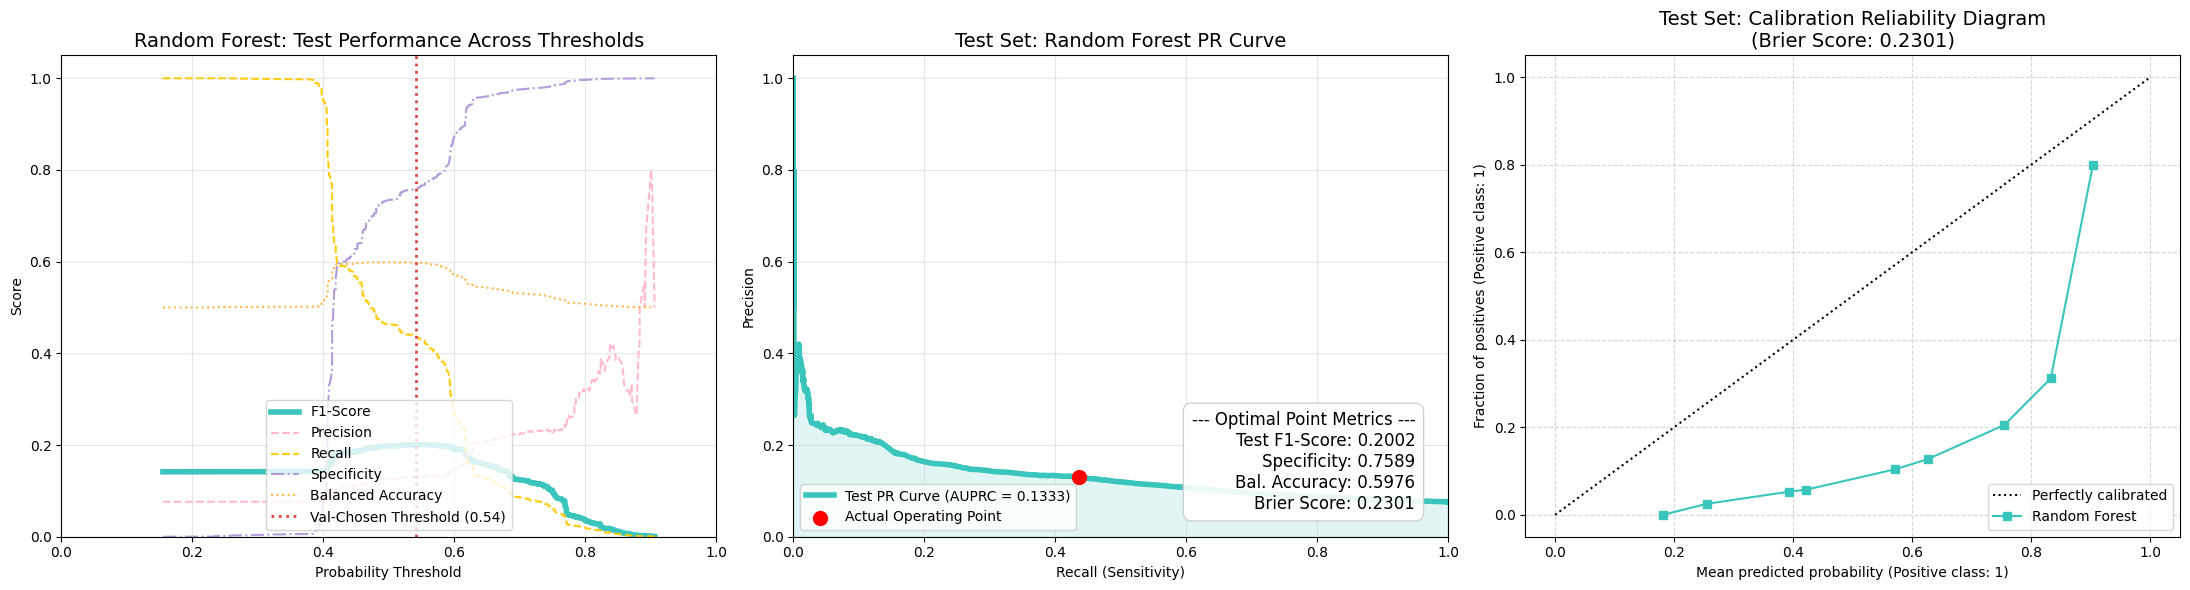

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, 
    f1_score, 
    confusion_matrix
)
from sklearn.calibration import CalibrationDisplay

# =========================================================
# PREPARE PLOTTING METRICS (ON TEST SET)
# =========================================================
# Get all thresholds and their PR values for the RF model
precision_rf, recall_rf, pr_thresholds_rf = precision_recall_curve(y_test_processed, y_probs_test)

# Calculate F1s, Specificity, and Balanced Accuracy across all thresholds for Plot 1
test_f1s_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-8)
test_specificity_rf = []
test_bal_acc_rf = []

for t in pr_thresholds_rf:
    preds = (y_probs_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_processed, preds).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0 
    
    test_specificity_rf.append(spec)
    test_bal_acc_rf.append((spec + sens) / 2)

# =========================================================
# VISUALIZE THE RESULTS (1x3 GRID)
# =========================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# ---------------------------------------------------------
# Plot 1: Threshold vs Metrics 
# ---------------------------------------------------------
ax1.plot(pr_thresholds_rf, test_f1s_rf[:-1], label='F1-Score', color='#39C5BB', linewidth=4)
ax1.plot(pr_thresholds_rf, precision_rf[:-1], label='Precision', color='#FFBACC', linestyle='--')
ax1.plot(pr_thresholds_rf, recall_rf[:-1], label='Recall', color='#FFCC11', linestyle='--')
ax1.plot(pr_thresholds_rf, test_specificity_rf, label='Specificity', color='#B39DDB', linestyle='-.')
ax1.plot(pr_thresholds_rf, test_bal_acc_rf, label='Balanced Accuracy', color='#FFB74D', linestyle=':')

ax1.axvline(x=miku_threshold_rf, color='#DD4444', linestyle=':', linewidth=2, 
            label=f'Val-Chosen Threshold ({miku_threshold_rf:.2f})')

ax1.set_title("Random Forest: Test Performance Across Thresholds", fontsize=14)
ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Score")
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.legend(loc='lower center')
ax1.grid(alpha=0.3)

# ---------------------------------------------------------
# Plot 2: Precision-Recall Curve 
# ---------------------------------------------------------
ax2.plot(recall_rf, precision_rf, color='#39C5BB', linewidth=4, label=f'Test PR Curve (AUPRC = {auprc_test:.4f})')
ax2.fill_between(recall_rf, 0, precision_rf, color='#39C5BB', alpha=0.15)

# Find the exact point on the curve that matches our chosen threshold
idx_rf = np.argmin(np.abs(pr_thresholds_rf - miku_threshold_rf))
ax2.scatter(recall_rf[idx_rf], precision_rf[idx_rf], color='red', s=100, zorder=5, label='Actual Operating Point')

ax2.set_title("Test Set: Random Forest PR Curve", fontsize=14)
ax2.set_xlabel("Recall (Sensitivity)")
ax2.set_ylabel("Precision")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

# --- Add the Metrics Text Box ---
metrics_text = (
    f"--- Optimal Point Metrics ---\n"
    f"Test F1-Score: {f1_score(y_test_processed, y_pred_optimal):.4f}\n"
    f"Specificity: {specificity_opt:.4f}\n"
    f"Bal. Accuracy: {bal_acc_opt:.4f}\n"
    f"Brier Score: {brier:.4f}"
)

props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
ax2.text(0.95, 0.05, metrics_text, transform=ax2.transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=10)

# ---------------------------------------------------------
# Plot 3: Calibration Curve 
# ---------------------------------------------------------
CalibrationDisplay.from_predictions(
    y_test_processed, 
    y_probs_test, 
    n_bins=10, 
    name="Random Forest",
    ax=ax3,
    color='#39C5BB'
)
ax3.set_title(f"Test Set: Calibration Reliability Diagram\n(Brier Score: {brier:.4f})", fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# SHAP

In [ ]:
import shap

# 1. Get the raw SHAP values from your winning Random Forest
explainer = shap.TreeExplainer(best_rf_model)
shap_vals_output = explainer.shap_values(X_test_processed)

# Check if SHAP gave us a list or a 3D array, and extract Class 1 (Reactive) safely
if isinstance(shap_vals_output, list):
    shap_raw = shap_vals_output[1]
elif len(shap_vals_output.shape) == 3:
    # Slice the 3D array: [All Rows, All Columns, Class 1]
    shap_raw = shap_vals_output[:, :, 1]
else:
    shap_raw = shap_vals_output
# -----------------------

# Put them in a DataFrame so we can easily group the columns by name
shap_df = pd.DataFrame(shap_raw, columns=X_test_processed.columns)
grouped_shap_df = shap_df.copy()

# 2. Define the exact prefixes of your One-Hot Encoded columns
categorical_prefixes = ['cat__Sex','cat__Age_Group','cat__Transmission',
                        'cat__Healthcare_Access_Friction','cat__Civil_Status','cat__OFW_Status','cat__Chemsex_Engagement',
                        'cat__Alcohol_Sex_Risk','cat__PrEP_Awareness','cat__Transactional_Sex','cat__STI_BBV_CoInfection_Any']

# 3.Summing the SHAP values
for prefix in categorical_prefixes:
    # Find all dummy columns that start with this prefix
    dummy_cols = [col for col in X_test_processed.columns if col.startswith(f"{prefix}_")]

    if len(dummy_cols) > 0:
        # The true SHAP value of the original category is the SUM of its dummy parts
        grouped_shap_df[prefix] = shap_df[dummy_cols].sum(axis=1)

        # Drop the diluted dummy columns so they don't clutter the plot
        grouped_shap_df.drop(columns=dummy_cols, inplace=True)


In [ ]:
# 4. Plot the Global Feature Importance (Miku Teal!)
plt.figure(figsize=(10, 6))
plt.title("True Feature Importance (Categorical Variables Grouped)", fontsize=14)

shap.summary_plot(
    grouped_shap_df.values,
    feature_names=grouped_shap_df.columns,
    plot_type="bar",          # Bar plots are best for grouped categorical SHAP!
    color="#39C5BB",          # Miku color to match your dashboard
    show=False
)

# Optional: Make it look extra clean
plt.grid(axis='x', alpha=0.3)
plt.show()

## TOP 10 INDIVIDUAL FEATURES 

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Calculate SHAP values 
explainer = shap.TreeExplainer(best_rf_model)
shap_vals_output = explainer.shap_values(X_test_processed)

# 2. Safely extract Class 1 (Reactive)
if isinstance(shap_vals_output, list):
    shap_raw = shap_vals_output[1]
elif len(shap_vals_output.shape) == 3:
    shap_raw = shap_vals_output[:, :, 1]
else:
    shap_raw = shap_vals_output

# 3. Plot the Top 10 Features (Miku Teal Bar Chart)
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_raw,                                # Use the safely extracted values
    features=X_test_processed,
    feature_names=X_test_processed.columns,
    plot_type="bar",                         # Bar chart
    color="#39C5BB",
    max_display=10,
    show=False
)

# Optional: Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

## Beeswarm

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# 1.(Extract Class 1 safely so it doesn't crash)
if isinstance(shap_vals_output, list):
    shap_raw = shap_vals_output[1]
elif len(shap_vals_output.shape) == 3:
    shap_raw = shap_vals_output[:, :, 1]
else:
    shap_raw = shap_vals_output

# 2. The Plot
plt.figure(figsize=(10, 6))
miku_cmap = mcolors.LinearSegmentedColormap.from_list("miku_gradient", ["#D1F2F0", "#39C5BB"])

shap.summary_plot(
    shap_raw,                                # <-- Use the safely extracted array!
    features=X_test_processed,
    feature_names=X_test_processed.columns,
    plot_type="dot",                         # Beeswarm style
    cmap=miku_cmap,
    max_display=10,                          # Top 10 only
    show=False
)

# Optional: Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# SAVING THE MODEL (RUN MO TO YA IF YOU THINK MAGANDA RESULT PARA MASAVE)

In [7]:
import json
import joblib

print("Saving Random Forest artifacts...")

# 1. Save the Scikit-Learn Random Forest model
joblib.dump(best_rf_model, "best_rf_model.joblib")
print("✓ Random Forest model saved as 'best_rf_model.joblib'")

# 2. Save the optimal threshold
rf_threshold_config = {"miku_threshold_rf": float(miku_threshold_rf)}
with open("rf_threshold_config.json", "w") as f:
    json.dump(rf_threshold_config, f)
print("✓ Optimal threshold saved as 'rf_threshold_config.json'")

# 3. Save the OrdinalEncoder (if not already saved)
# joblib.dump(encoder, "ordinal_encoder.joblib")

print("All Random Forest artifacts saved successfully!")

Saving Random Forest artifacts...
✓ Random Forest model saved as 'best_rf_model.joblib'
✓ Optimal threshold saved as 'rf_threshold_config.json'
All Random Forest artifacts saved successfully!


# RELOAD

In [8]:
import json
import joblib
import pandas as pd
import numpy as np

print("Loading Random Forest artifacts...")

# 1. Load the Preprocessor (Encoder)
loaded_encoder = joblib.load("ordinal_encoder.joblib")

# 2. Load the Threshold
with open("rf_threshold_config.json", "r") as f:
    loaded_config = json.load(f)
loaded_rf_threshold = loaded_config["miku_threshold_rf"]

# 3. Load the Random Forest Model
loaded_rf_model = joblib.load("best_rf_model.joblib")

print(f"✓ Everything loaded! Operating Threshold: {loaded_rf_threshold:.4f}")

# ==========================================
# HOW TO PREDICT ON BRAND NEW DATA
# ==========================================
# 1. Transform raw strings to integers
# new_data_encoded = loaded_encoder.transform(new_patient_data)

# 2. Get Probabilities
# new_rf_probs = loaded_rf_model.predict_proba(new_data_encoded)[:, 1]

# 3. Apply the Golden Threshold
# final_rf_predictions = (new_rf_probs >= loaded_rf_threshold).astype(int)

Loading Random Forest artifacts...
✓ Everything loaded! Operating Threshold: 0.5425
